In [5]:
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import pandas as pd
import numpy as np
import sklearn
import scipy

In [6]:
def make_pipeline(model):
    return pipeline.Pipeline([
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", RobustScaler()),
        # ("scale", StandardScaler()),
        ("predict", model)
    ])

In [7]:
rng = np.random.default_rng(seed=58)

In [19]:
df[df["id"] == 769]

,smiles,id,energy,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,canon_smiles,solubility
7359,[O:1]=[Si:2]=[O:3],769,-9.967178,0.856912,0.289216,0.661165,0.053468,-0.349428,0.002137,-73.021889,...,0,0,0,0,0,0,0,0,O=[Si]=O,-3.602668


In [9]:
df = pd.read_csv("data/processed_dataset_wo_metals.csv")

In [22]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [23]:
X = X.drop([7359, 587])

In [11]:
X_wo_atom = X.drop(["avg_atomic_quadrupole_principal_invariant_3"], axis=1)

In [25]:
X[["id", "avg_atomic_quadrupole_principal_invariant_3"]].nlargest(10, columns="avg_atomic_quadrupole_principal_invariant_3")

KeyError: "['id'] not in index"

In [18]:
df[["id", "molecular_quadrupole_principal_invariant_3"]].nlargest(10, columns="molecular_quadrupole_principal_invariant_3")

,id,molecular_quadrupole_principal_invariant_3
587,1539,1.561343e+09
1657,2529,1.543235e+08
3949,4610,7.055779e+07
96,1088,4.600046e+07
6969,7337,4.160781e+07
1590,2465,3.977570e+07
2999,3748,3.447213e+07
2997,3746,3.447213e+07
7001,7367,3.429472e+07
7012,7376,2.534992e+07


<Axes: >

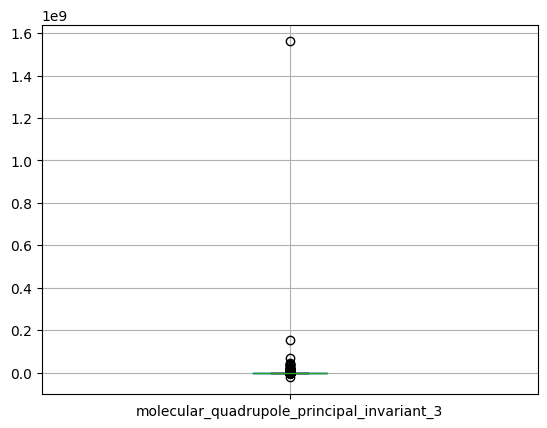

In [ ]:
X.boxplot("molecular_quadrupole_principal_invariant_3")
plt.show()

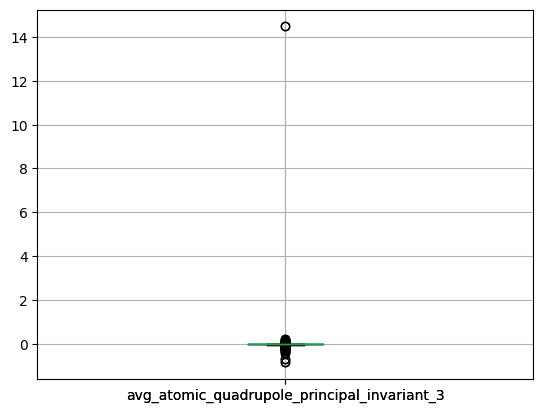

In [17]:
X.boxplot("avg_atomic_quadrupole_principal_invariant_3")
plt.show()

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pl = make_pipeline(sklearn.linear_model.LinearRegression())

In [16]:
for i, (train_idx, test_idx) in enumerate(cv.split(X_wo_atom)):
    X_train, X_test = X_wo_atom.iloc[train_idx], X_wo_atom.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    pl.fit(X_train, y_train)
    y_pred = pl.predict(X_test)

    
    print(f"Fold {i+1} R²:", r2_score(y_test, y_pred))
    # print("y_test min/max:", y_test.min(), y_test.max())
    # print("Pred min/max:", y_pred.min(), y_pred.max())
 
 
    # coefs = pl["predict"].coef_
    # condition = (np.abs(coefs) > 100)
    # for coef, feature in zip(coefs[condition], df.columns[np.asarray(condition).nonzero()[0]]):
    #     print(feature, coef)
 
    # print("\n")
    # maXrain = Xrain.max(axis=0)
    # min_train = Xrain.min(axis=0)

    # out_of_range = ((Xest > maXrain) | (Xest < min_train))

    # print("Samples with any out-of-range feature:",
    #   np.sum(out_of_range.any(axis=1)))
    
    # print("\n")
    # train_mean = Xrain.mean(axis=0)
    # distances = np.linalg.norm(Xest - train_mean, axis=1)

    # print("Max test distance:", distances.max())

    # if i == 4:
    #     print("\n")
    #     bad_idx = np.argmax(y_pred)
    #     print("Extreme prediction:", y_pred[bad_idx])
    #     print("Corresponding features:", Xest.iloc[bad_idx][:50])

    #     Xrain_trans = pl[:-1].fit_transform(Xrain)
    #     Xest_trans = pl[:-1].transform(Xest)

    #     print(Xest_trans[bad_idx])

    #     print("Max abs transformed value:",
    #         np.abs(Xest_trans).max())

    #     plot_features(pd.DataFrame(Xest_trans, columns=X.columns))

    # print("\n\n")

Fold 1 R²: 0.8065399143630246
Fold 2 R²: 0.837236484691048
Fold 3 R²: 0.8123391502066157
Fold 4 R²: 0.8222120296522589
Fold 5 R²: 0.8270255450798072
